In [1]:
%pip install -qU ddgs arxiv langchain-community langchain langchain-google-community\[gmail\]

Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain.chat_models.base import init_chat_model

big_llm = init_chat_model(model="gpt-5", model_provider="openai")

small_llm = init_chat_model(model="gpt-4o-mini", model_provider="openai")

In [4]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

In [5]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

In [6]:
from langchain_google_community import GmailToolkit

from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_tool_list = gmail_toolkit.get_tools()


/var/folders/z0/1s99gknj53x_1hd6ndb09frh0000gn/T/ipykernel_66296/2521921311.py:8: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
/var/folders/z0/1s99gknj53x_1hd6ndb09frh0000gn/T/ipykernel_66296/2521921311.py:13: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [7]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x152636a80>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x152636a80>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x152636a80>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x152636a80>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x152636a80>)]

In [8]:
from langchain_community.tools.arxiv.tool import ArxivQueryRun 

arxiv_tool = ArxivQueryRun()


In [9]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool, arxiv_tool] + gmail_tool_list
llm_with_tools = big_llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [10]:
from langgraph.graph import MessagesState, StateGraph

class AgentState(MessagesState):
    summary: str

graph_builder = StateGraph(AgentState)

In [ ]:
from langchain_core.messages import SystemMessage 

def _sanitize_messages(messages):
    """Remove or clear assistant tool_calls that are not followed by tool response messages."""
    sanitized = []
    for i, msg in enumerate(messages):
        tc = getattr(msg, 'tool_calls', None)
        if tc:
            # check if the next message is a tool response
            next_msg = messages[i+1] if i+1 < len(messages) else None
            has_tool_response = False
            if next_msg is not None:
                role = getattr(next_msg, 'role', None)
                # Tool messages often have role == 'tool' or attribute tool_call_id
                if role == 'tool' or getattr(next_msg, 'tool_call_id', None) is not None:
                    has_tool_response = True
            if not has_tool_response:
                # attempt to clear tool_calls safely
                try:
                    msg.tool_calls = []
                except Exception:
                    # if the message is a dict-like object, remove the key
                    try:
                        if isinstance(msg, dict) and 'tool_calls' in msg:
                            m = dict(msg)
                            m.pop('tool_calls', None)
                            msg = m
                    except Exception:
                        pass
        sanitized.append(msg)
    return sanitized

def agent(state: AgentState): 
    messages = state['messages'] 
    summary = state['summary']
    if summary != '':
        messages = [SystemMessage(content=f'Here is the summary of the earlier conversation: {summary}')] + messages 

    # sanitize history to avoid assistant messages with unresolved tool_calls
    messages = _sanitize_messages(messages)

    response = llm_with_tools.invoke(messages) # messages: 전체 history -> token과 비용이 많이 든다.
    return {'messages': [response]}

In [12]:
from typing import Literal
from langgraph.types import interrupt, Command

def human_review(state: AgentState) -> Command[Literal['tools', 'agent']]:
    messages = state['messages']
    last_message = messages[-1]
    tool_call = last_message.tool_calls[-1]
    human_review = interrupt({
        'question': '이렇게 진행하면 될까요?',
        'tool_call': tool_call
    })
    review_action = human_review['action']
    review_data = human_review.get('data', None)
    
    if review_action == 'continue':
        # 에이전트의 판단이 맞다면, 도구를 사용하기 위해 아무것도 수정하지 않고 `tools` 노드로 이동합니다
        return Command(goto='tools')
    
    if review_action == 'update_args':
        # 도구를 더 효율적으로 사용하기 위해 AIMessage의 `tool_calls` 필드를 업데이트합니다
        updated_ai_message = {
            'id': last_message.id,
            'role': 'ai',
            'content': last_message.content,
            'tool_calls': [{
                'id': tool_call['id'],
                'name': tool_call['name'],
                'args': review_data
            }],
        }
        return Command(goto='tools', update={'messages': [updated_ai_message]})
    
    if review_action == 'update_tool':
        # 다른 도구를 사용하기 위해 `ToolMessage`를 업데이트합니다 
        updated_tool_message = {
            'tool_call_id': tool_call['id'],
            'name': tool_call['name'],
            'role': 'tool',
            'content': review_data
        }
        return Command(goto='agent', update={'messages': [updated_tool_message]})


In [13]:
def summarize_messages(state: AgentState):
    messages = state['messages']
    summary = state['summary']
    summary_prompt = f'''summarize this chat history below: \n\nchat_history: {messages}'''
    if summary != '':
        summary_prompt = f'''summarize this chat history below while looking at the summary of earlier conversations
        chat_history: {messages}
        summary: {summary}
    ''' 

    summary = big_llm.invoke(summary_prompt)
    response = llm_with_tools.invoke(summary_prompt)
    return {'summary': response.content}

In [14]:
from langchain_core.messages import RemoveMessage

def delete_messages(state: AgentState):
    messages = state['messages']
    delete_messages = [RemoveMessage(id=message.id) for message in messages[:-3]]
    return {'messages': delete_messages}

In [ ]:
from typing import Literal

def should_continue(state: AgentState):
    messages = state['messages']
    last_ai_message = messages[-1]

    # safe check for tool_calls (some message types may not have the attribute)
    if getattr(last_ai_message, 'tool_calls', None):
        return 'human_review'

    return 'summarize_messages'

In [16]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
graph_builder.add_node(human_review)
graph_builder.add_node(delete_messages)
graph_builder.add_node(summarize_messages)


In [17]:
from langgraph.graph import START, END


graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['human_review', 'summarize_messages']
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_messages', 'delete_messages')
graph_builder.add_edge('delete_messages', END)

In [18]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

graph = graph_builder.compile(checkpointer=checkpointer)

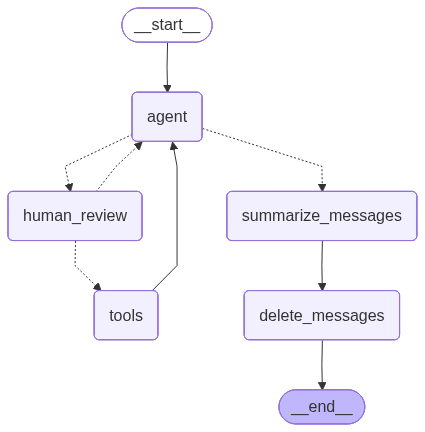

In [19]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'summarize_paper'
    }
}

query = 'LLM Survey 논문의 내용을 검색해서 요약해주세요.'
for chunk in graph.stream({'messages': [HumanMessage(query)], 'summary': ''}, config=config, stream_mode='values'):
    if isinstance(chunk, dict) and 'messages' in chunk and chunk['messages']:
        last = chunk['messages'][-1]
        if hasattr(last, 'pretty_print'):
            last.pretty_print()
        else:
            print(last)

================================ Human Message =================================

LLM Survey 논문의 내용을 검색해서 요약해주세요.


BadRequestError: Error code: 400 - {'error': {'message': "An assistant message with 'tool_calls' must be followed by tool messages responding to each 'tool_call_id'. The following tool_call_ids did not have response messages: call_X7YFsctzS6cLfLELmTIbd486", 'type': 'invalid_request_error', 'param': 'messages.[2].role', 'code': None}}

In [ ]:
graph.get_state(config).next

In [ ]:
for chunk in graph.stream(
    Command(resume={'action': 'continue'}),
    config=config,
    stream_mode='updates'
):
    print(chunk)